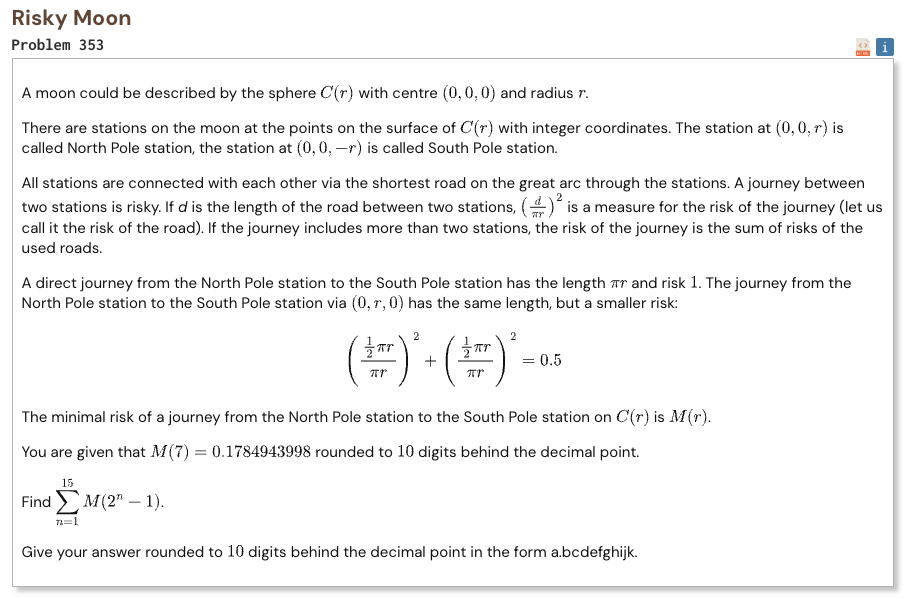

## Initial approach

* generate all integer-coordinate stations on each sphere
* treat every station as a graph node
* road risk depends only on the spherical angle between two stations
* use Dijkstra to find the safest path from north pole to south pole
* use heapq to process the lowest-risk station efficiently
* for larger spheres, connect each station only to nearby stations to keep the graph practical
* sum the risks for radii of the form 2^n - 1

In [1]:
import math
import heapq

def sphere_points(r):
    points = []
    rr = r * r

    for x in range(-r, r + 1):
        for y in range(-r, r + 1):
            z2 = rr - x * x - y * y

            if z2 < 0:
                continue

            z = math.isqrt(z2)

            if z * z == z2:
                points.append((x, y, z))

                if z:
                    points.append((x, y, -z))

    return points

def risk(a, b, r):
    dot = a[0] * b[0] + a[1] * b[1] + a[2] * b[2]
    value = max(-1.0, min(1.0, dot / (r * r)))
    angle = math.acos(value)
    return (angle / math.pi) ** 2

def M(r):
    points = sphere_points(r)
    start = points.index((0, 0, r))
    target = points.index((0, 0, -r))

    n = len(points)
    dist = [float("inf")] * n
    dist[start] = 0.0

    queue = [(0.0, start)]

    while queue:
        current, i = heapq.heappop(queue)

        if i == target:
            return current

        if current != dist[i]:
            continue

        for j in range(n):
            if i == j:
                continue

            new_value = current + risk(points[i], points[j], r)

            if new_value < dist[j]:
                dist[j] = new_value
                heapq.heappush(queue, (new_value, j))

def solve():
    total = 0.0

    for n in range(1, 16):
        total += M(2 ** n - 1)

    return total

```python
%%time
result = solve()
print("Result:", f"{result:.10f}")
```

it takes too long to run. needs an optimization.